In [70]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [71]:
def model(x0, theta, key,days, delta_t):
    gamma, xi = theta
    log_beta_damping = 1 / 35
    log_beta_mean = jnp.log(0.35)
    log_beta_standard_deviation = 0.20

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    return jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=jnp.arange(0, days + delta_t, delta_t),
    )

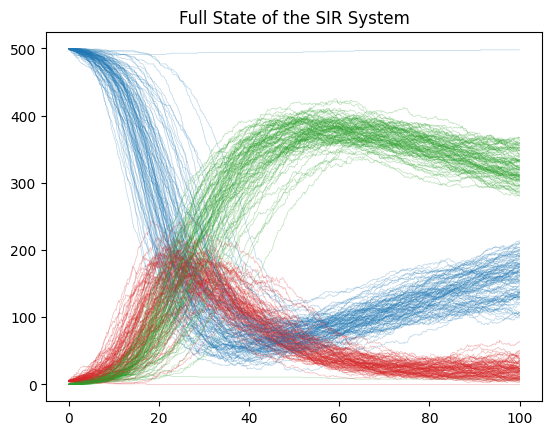

In [72]:
theta = (0.1,1/90)
delta_t = 0.1
days = 100
rng_key = jax.random.key(0)

num_models  = 100
keys = jax.random.split(rng_key,num_models)
x0 = jnp.full(shape = (num_models,4),fill_value = jnp.array([500.,5.,0.,jnp.log(0.3)]))

_,full_state = jax.vmap(model,in_axes = (0,None,0,None,None))(x0,theta,keys, days,delta_t)

colors = ['tab:blue','tab:red','tab:green']
plt.title('Full State of the SIR System')
for model_index in range(num_models):
    for state in range(3): 
        plt.plot(jnp.arange(0,days+delta_t,delta_t),full_state[model_index,:,state],lw = 0.5,alpha = 0.3, color = colors[state])
plt.show()

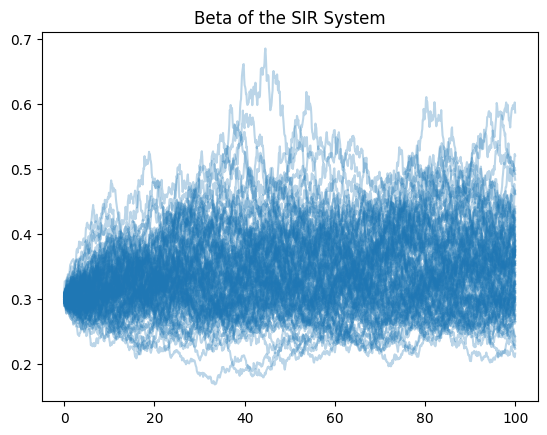

In [73]:
plt.title('Beta of the SIR System')
plt.plot(jnp.arange(0,days+delta_t,delta_t),jnp.exp(full_state[:,:,4]).T,color = 'tab:blue',alpha = 0.3)
plt.show()

In [74]:
### Forecasting

forecast_horizon = 2 * 7  # 2 weeks
cutoff_day = 15

num_ensemble_members = 25

forecasts = []

theta_forecast = (0.10,1/90)

for run_num in range(num_models):
    print(run_num, end="\r")
    ensemble_IC = jnp.full(
        fill_value=full_state[run_num, int(cutoff_day / delta_t), :],
        shape=(num_ensemble_members, 4),
    )
    forecast_key, rng_key = jax.random.split(rng_key)
    forecast_keys = jax.random.split(forecast_key, num_ensemble_members)
    _, forecast = jax.vmap(model, in_axes=(0, None, 0, None, None))(
        ensemble_IC, theta_forecast, forecast_keys, forecast_horizon, delta_t
    )
    forecasts.append(forecast)




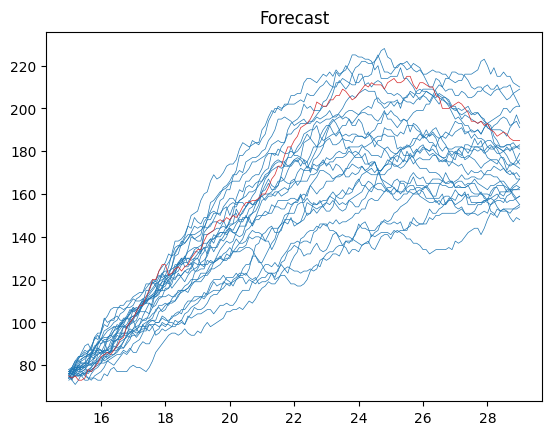

In [75]:
plt.plot(
    jnp.arange(cutoff_day, cutoff_day + forecast_horizon + delta_t, delta_t),
    forecast[:, :, 1].T,
    lw=0.5,
    color="tab:blue",
)
plt.plot(
    jnp.arange(cutoff_day, cutoff_day + forecast_horizon + delta_t, delta_t),
    full_state[
        run_num,
        int(cutoff_day / delta_t) : int(cutoff_day / delta_t)
        + int(forecast_horizon / delta_t)
        + 1,
        1,
    ].T,
    lw=0.5,
    color="tab:red",
)

plt.title("Forecast")
plt.show()

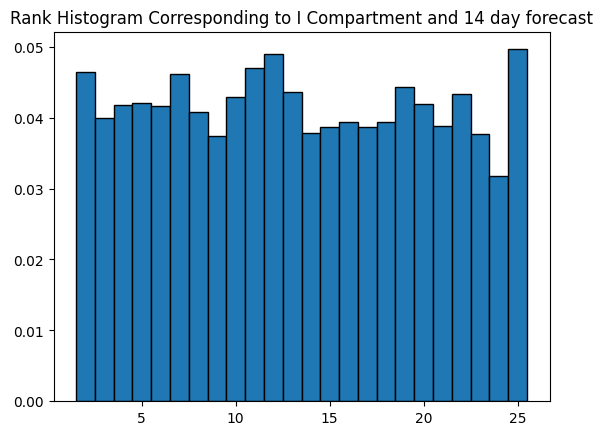

In [76]:
def get_rank_histogram(truth,ensemble): 
    obs = truth[...,jnp.newaxis]
    ens = jnp.swapaxes(ensemble,1,2)

    def rank_eval(ens,obs): 
        is_smaller = ens < obs
        ranks = jnp.sum(is_smaller,axis = 1)

        return ranks

    return jax.vmap(rank_eval,in_axes = (0,0))(ens,obs)

forecasts = jnp.array(forecasts)


ranks = get_rank_histogram(
    full_state[
        :,
        int(cutoff_day / delta_t) : int(cutoff_day / delta_t)
        + int(forecast_horizon / delta_t)
        + 1,
        1,
    ],
    forecasts[:,:,:,1]
)

plt.title(f'Rank Histogram Corresponding to I Compartment and {forecast_horizon} day forecast')
plt.hist(ranks.reshape(-1),bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black',density = True)
plt.show()